# 04 — Model Interpretability
Load best_model.pkl → SHAP (global) → LIME (local, 3 instances)
No model retraining in this notebook.

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lime.lime_tabular

RS = 42

In [3]:
with open("../models/best_model.pkl", "rb") as f:
    payload = pickle.load(f)

best_pipe      = payload["pipeline"]
feature_names  = payload["feature_names"]
model_name     = payload["model_name"]
X_test         = payload["X_test"]
y_test         = payload["y_test"]

print(f"model       : {model_name}")
print(f"features    : {feature_names}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test dist : {y_test.value_counts().to_dict()}")

model       : Random Forest
features    : ['Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp', 'BMI', 'Heart Rate', 'Previous Complications', 'Preexisting Diabetes', 'Gestational Diabetes', 'Mental Health', 'Is_Fever']
X_test shape: (234, 12)
y_test dist : {0: 139, 1: 95}


## Extract Scaler and Classifier from Pipeline

In [4]:
# extract the scaler and classifier from the fitted pipeline
# resampler has no transform() method, so we skip it at inference time
scaler_xai = best_pipe.named_steps.get("scaler")
clf_xai    = best_pipe.named_steps["clf"]

if scaler_xai is not None:
    X_test_scaled  = scaler_xai.transform(X_test)
    # reconstruct scaled training data from pipeline internals if available
    # for lime background distribution we approximate using test set
    X_bg_scaled    = X_test_scaled
else:
    X_test_scaled  = X_test.values if hasattr(X_test, "values") else X_test
    X_bg_scaled    = X_test_scaled

X_test_arr = X_test_scaled
print(f"X_test_arr shape: {X_test_arr.shape}")

X_test_arr shape: (234, 12)


## LIME — Local Interpretability (3 Instances)

In [9]:
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_bg_scaled,
    feature_names=feature_names,
    class_names=["Low Risk", "High Risk"],
    mode="classification",
    random_state=RS,
)

y_prob_xai = clf_xai.predict_proba(X_test_arr)[:, 1]

low_cands  = np.where(y_prob_xai < 0.30)[0]
high_cands = np.where(y_prob_xai > 0.70)[0]

# graceful fallback if buckets are empty
if len(low_cands) == 0:
    low_cands = np.argsort(y_prob_xai)[:3]
    print("[warn] no P < 0.30 instances, using 3 lowest-probability instances")
if len(high_cands) == 0:
    high_cands = np.argsort(y_prob_xai)[-3:]
    print("[warn] no P > 0.70 instances, using 3 highest-probability instances")

low_idx  = int(low_cands[0])
mid_idx  = int(np.argmin(np.abs(y_prob_xai - 0.5)))
high_idx = int(high_cands[0])

lime_cases = {
    "low-risk  — P(high risk) < 0.30": low_idx,
    "mid-risk  — P(high risk) near 0.50": mid_idx,
    "high-risk — P(high risk) > 0.70": high_idx,
}

print(f"selected instances: low={low_idx}, mid={mid_idx}, high={high_idx}")

selected instances: low=0, mid=36, high=1



low-risk  — P(high risk) < 0.30
  index        : 0
  P(high risk) : 0.0100
  true label   : Low Risk


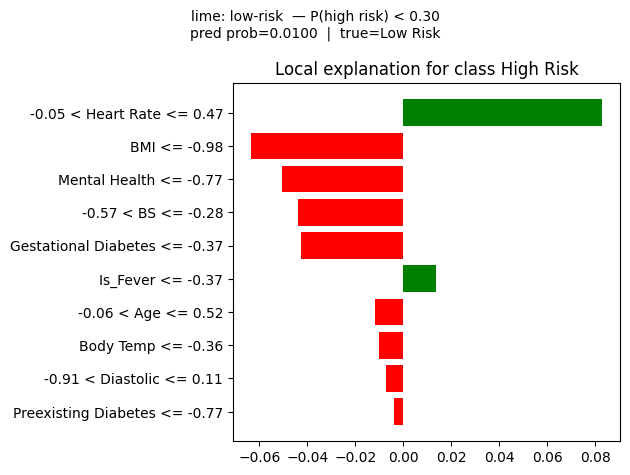


mid-risk  — P(high risk) near 0.50
  index        : 36
  P(high risk) : 0.4900
  true label   : Low Risk


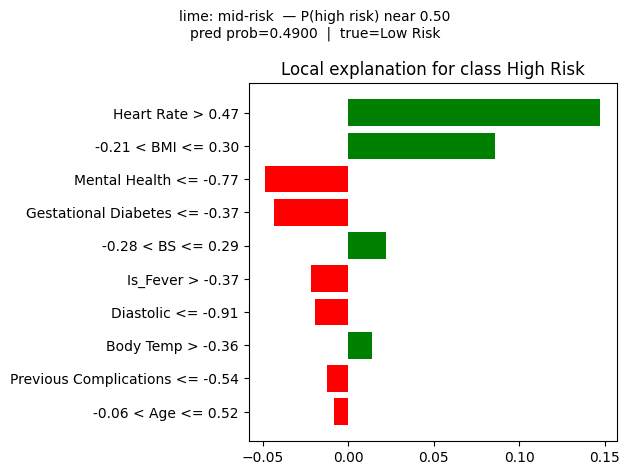


high-risk — P(high risk) > 0.70
  index        : 1
  P(high risk) : 0.9100
  true label   : High Risk


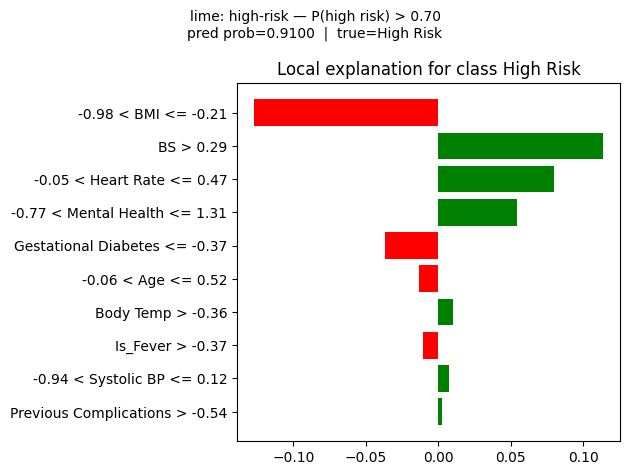

In [10]:
for label, idx in lime_cases.items():
    prob       = float(y_prob_xai[idx])
    true_label = "High Risk" if int(y_test.iloc[idx]) == 1 else "Low Risk"

    print(f"\n{label}")
    print(f"  index        : {idx}")
    print(f"  P(high risk) : {prob:.4f}")
    print(f"  true label   : {true_label}")

    exp = explainer_lime.explain_instance(
        data_row  =X_test_arr[idx],
        predict_fn=clf_xai.predict_proba,
        num_features=min(10, len(feature_names)),
    )

    fig = exp.as_pyplot_figure()
    fig.suptitle(f"lime: {label}\npred prob={prob:.4f}  |  true={true_label}", fontsize=10)
    plt.tight_layout()
    plt.show()